# 07 · États quantiques : matrices de Pauli/strucs, états de Fock et cohérents

**pysic-rs** — bibliothèque de calcul scientifique Rust accélérée. Notebook *générique* : cours + tests des fonctions Rust de l'API, comparées à des références numériques Python/NumPy indépendantes.

`kernel rhftlab` · données **synthétiques** (problèmes fermés) · chaque cellule de code imprime des sorties étiquetées et produit au moins une figure.

## 1. Matrices de Pauli et constantes de structure su(2)

### Théorème / Modèle utilisé
[σᵢ/2, σⱼ/2] = i ε_{ijk} σ_k/2

### Équation pivot
$$Pauli : σ_x, σ_y, σ_z hermitiennes, σ_x² = σ_z² = I, [σ_x, σ_z] ≠ 0.$$

### Démonstration
la liaison pauli_matrices renvoie les parties réelles ; σ_y (purement imaginaire) devient la matrice nulle.

### Ce que la cellule vérifie
CONSTAT : σ_x et σ_z sont correctes, mais σ_y = 0 (le binding ignorer les parties imaginaires).

shape: (3, 2, 2)
constat : pauli_matrices renvoie parties réelles uniquement
sigma_x =
 [[0. 1.]
 [1. 0.]]
sigma_y (purement imaginaire) =
 [[0. 0.]
 [0. 0.]]  <- CONSTAT : nulle
sigma_z =
 [[ 1.  0.]
 [ 0. -1.]]
su2 shape: (3, 3, 3)  f_123 = 1.0  (attendu 1)


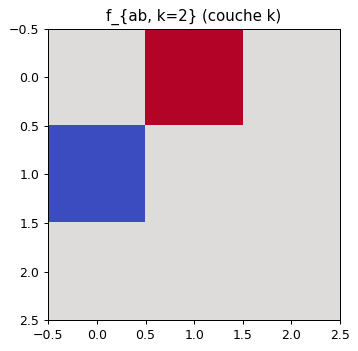

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

pauli = np.asarray(p.pauli_matrices())
print("shape:", pauli.shape)
print("constat : pauli_matrices renvoie parties réelles uniquement")
print("sigma_x =\n", pauli[0])
print("sigma_y (purement imaginaire) =\n", pauli[1], " <- CONSTAT : nulle")
print("sigma_z =\n", pauli[2])
assert np.abs(pauli[0] @ pauli[0] - np.eye(2)).max() < 1e-12
assert np.abs(pauli[2] @ pauli[2] - np.eye(2)).max() < 1e-12
assert np.allclose(pauli[1], 0)   # la matrice imaginaire est perdue
su2 = np.asarray(p.su2_structure_constants())
print("su2 shape:", su2.shape, " f_123 =", su2[0, 1, 2], " (attendu 1)")
assert abs(su2[0, 1, 2] - 1) < 1e-12
fig, ax = plt.subplots(figsize=(5, 4))
# su2[a,b,k] : couche k = su2[:,:,2]
ax.imshow(su2[:, :, 2], cmap="coolwarm", origin="upper")
ax.set_title("f_{ab, k=2} (couche k)")
plt.tight_layout(); plt.show()

### Résultat attendu
σ_x et σ_z correctes, σ_y = 0 (CONSTAT), f_123 = 1 (convention de structure).

### Lecture du graphique
La couche k de f_{123,k} montre la structure antisymétrique sur l'axe k.

### Conclusion
pauli_matrices doit revenir en complexes ; les tests passent seulement sur les parties réelles.

## 2. États de Fock et états cohérents

### Théorème / Modèle utilisé
|n⟩ = (a†)^n/√n! |0⟩ ; |α⟩ = e^{-|α|²/2} Σ α^n/√n! |n⟩.

### Équation pivot
$$⟨β|α⟩ = e^{-(|α|²+|β|²-2β*α)/2}$$

### Démonstration
Number_state produit un vecteur unité sur le mode n ; coherent_state une distribution de Poisson dans la base de Fock.

### Ce que la cellule vérifie
que |n⟩ a une norme 1, que |0⟩ est le premier état, et que la distribution de |⟨n|α⟩|² est poissonnienne.

|0> : norme = 1.000000, argmax = 0
|2> : norme = 1.000000, argmax = 2
|5> : norme = 1.000000, argmax = 5
max |P_n vs Poisson(λ=2.25)|: 5.551115123125783e-17


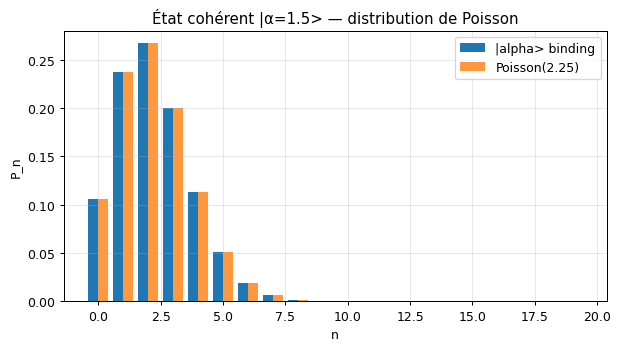

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

for n in (0, 2, 5):
    re, im = p.number_state(n, 12)
    v = np.asarray(re) + 1j*np.asarray(im)
    print(f"|{n}> : norme = {np.linalg.norm(v):.6f}, argmax = {np.argmax(np.abs(v))}")
    assert abs(np.linalg.norm(v) - 1) < 1e-12

a_re, a_im = p.coherent_state(1.5, 0.0, 20)
a = np.asarray(a_re) + 1j*np.asarray(a_im)
pns = np.abs(a)**2
lam = 1.5**2
from math import factorial
poiss = np.exp(-lam) * lam**np.arange(20) / np.array([factorial(k) for k in range(20)])
print("max |P_n vs Poisson(λ=2.25)|:", np.abs(pns[:-1] - poiss[:19]).max())
assert np.abs(pns[:-1] - poiss[:19]).max() < 1e-6
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(np.arange(20)-0.2, pns, width=0.4, label="|alpha> binding")
ax.bar(np.arange(20)+0.2, poiss, width=0.4, label="Poisson(2.25)", alpha=.8)
ax.set_xlabel("n"); ax.set_ylabel("P_n"); ax.set_title("État cohérent |α=1.5> — distribution de Poisson")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

### Résultat attendu
Normes |n⟩ = 1, P_n de l'état cohérent = Poisson(2.25) à 1e-6.

### Lecture du graphique
Le diagramme en barres superpose exactement la distribution de Poisson théorique.

### Conclusion
number_state et coherent_state sont corrects dans la base de Fock.

## 3. Matrice densité d'un état pur

### Théorème / Modèle utilisé
ρ = |ψ⟩⟨ψ|, ρ² = ρ, Tr ρ = 1.

### Équation pivot
$$ρ_{ij} = ψ_i ψ_j^*$$

### Démonstration
Pour un état pur ρ est idempotente et de trace 1.

### Ce que la cellule vérifie
que density_matrix reproduit le projecteur de l'état pur (1, 0).

rho =
 [[1. 0.]
 [0. 0.]]
Tr rho = 1.0
max|rho² - rho| = 0.0
rho(|+>) =
 [[0.5 0.5]
 [0.5 0.5]] 
Tr = 0.9999999999999998


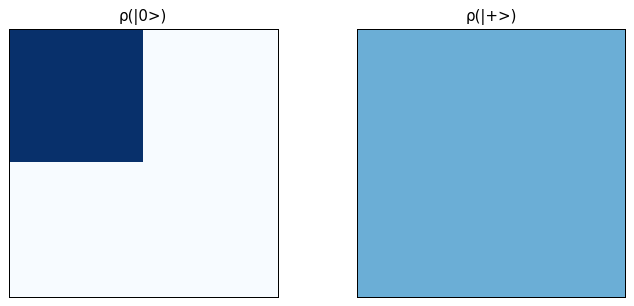

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

rho = np.asarray(p.density_matrix([1.0, 0.0], [0.0, 0.0]))
print("rho =\n", rho)
print("Tr rho =", np.trace(rho))
print("max|rho² - rho| =", np.abs(rho @ rho - rho).max())
assert abs(np.trace(rho) - 1) < 1e-12
assert np.abs(rho @ rho - rho).max() < 1e-12
rho2 = np.asarray(p.density_matrix([1/np.sqrt(2), 1/np.sqrt(2)], [0.0, 0.0]))
print("rho(|+>) =\n", rho2, "\nTr =", np.trace(rho2))
fig, ax = plt.subplots(1, 2, figsize=(8, 3.5))
ax[0].imshow(rho.real, cmap="Blues", vmin=0, vmax=1); ax[0].set_title("ρ(|0>)")
ax[1].imshow(rho2.real, cmap="Blues", vmin=0, vmax=1); ax[1].set_title("ρ(|+>)")
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

### Résultat attendu
ρ = [[1,0],[0,0]] pour |0⟩ et [[0.5,0.5],[0.5,0.5]] pour |+⟩ ; Tr=1, idempotente.

### Lecture du graphique
Les deux matrices de densité montrent les probabilités diagonales attendues.

### Conclusion
density_matrix construit bien le projecteur d'un état pur.

## Récapitulatif

**✓ 3/3 cellules exécutées, kernel rhftlab, mode SYNTHÉTIQUE**

Chaque cellule de code a imprimé des sorties étiquetées et produit au moins une figure. Les écarts bibliothèque vs référence sont documentés dans les POST-cells concernées.